# 04 · Machine Learning Models

**Goal:** beat the best baseline, **smart persistence (RMSE 2.10 kWh on 2019)**, using the features
from notebook 03.

**Models, from simple to powerful:**

| Model | Idea in one line |
|---|---|
| Linear Regression | Adds up the features, each multiplied by a learned weight |
| Random Forest | Averages hundreds of decision trees, each trained on a random sample |
| Gradient Boosting | Builds trees one after another, each fixing the previous trees' mistakes |

**The workflow (standard in research):**

1. Train on **2017**, compare models on **2018** (validation)
2. Choose settings using **2018 only**
3. Retrain the chosen models on **2017 + 2018**
4. Score **once** on **2019** (test)

In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_hourly, split, LOCAL_TZ
from src.baselines import make_baselines
from src.features import FEATURE_SETS
from src.metrics import evaluate, rmse
from src.models import fit_predict

FIGURES, RESULTS = ROOT / "results" / "figures", ROOT / "results"

y = load_hourly()
baselines, daytime = make_baselines(y)          # same baselines and scoring hours as notebook 02

X = pd.read_parquet(ROOT / "data" / "processed" / "features_hourly.parquet")
X.index = X.index.tz_convert(LOCAL_TZ).rename("time")

REALISTIC = FEATURE_SETS["time_sun"] + FEATURE_SETS["past_pv"] + FEATURE_SETS["obs_weather"]
UPPER_BOUND = REALISTIC + FEATURE_SETS["perfect_forecast_weather"]
print(len(REALISTIC), "realistic features |", len(UPPER_BOUND), "with perfect-forecast weather")

24 realistic features | 37 with perfect-forecast weather


## The three models

A few details that matter:

- **`SimpleImputer`** fills the few missing feature values (e.g. after an outage day) with the median.
  Linear Regression and Random Forest can't handle gaps. Gradient Boosting handles them by itself.
- **`StandardScaler`** puts all features on the same scale. Linear Regression needs this, trees don't.
- **`make_pipeline`** chains these steps, so exactly the same steps run on training and test data.
- **`random_state=42`** fixes the randomness, so you get the same numbers every time you run it.
- `fit_predict` (in `src/models.py`) trains only on **daylight hours** and sets night to 0.

In [11]:
def linear():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LinearRegression())

def forest(min_samples_leaf=3, max_features=1.0):
    return make_pipeline(SimpleImputer(strategy="median"),
                         RandomForestRegressor(n_estimators=300, min_samples_leaf=min_samples_leaf,
                                               max_features=max_features, n_jobs=-1, random_state=42))

def boosting(learning_rate=0.05, min_samples_leaf=20):
    return HistGradientBoostingRegressor(max_iter=500, learning_rate=learning_rate, max_leaf_nodes=15,
                                         min_samples_leaf=min_samples_leaf, random_state=42)

## Step 1 · Train on 2017, compare on 2018

In [12]:
val_forecasts = dict(baselines)
for name, make in [("Linear Regression", linear), ("Random Forest", forest), ("Gradient Boosting", boosting)]:
    val_forecasts[name], _ = fit_predict(make(), X, REALISTIC, ["train"])

val_table = evaluate(split(y, "val"), {k: split(v, "val") for k, v in val_forecasts.items()}, split(daytime, "val"))
val_table

,MAE (kWh),RMSE (kWh),nRMSE (%),Skill vs persistence
Persistence,3.528,4.277,35.101,0.000
Yesterday,2.470,4.430,36.354,-0.036
Climatology,2.660,4.089,33.552,0.044
Smart persistence,1.308,2.216,18.187,0.482
Linear Regression,1.377,2.115,17.359,0.505
Random Forest,1.130,1.974,16.201,0.538
Gradient Boosting,1.198,2.010,16.494,0.530


## Step 2 · Choose settings on 2018 (a small search)

Every model has settings ("hyperparameters") that we choose, not learn. We try a few combinations
and keep the one with the lowest **2018** RMSE. **The 2019 test year is not touched here.**

- **Random Forest:** `min_samples_leaf` (how small a leaf can get, since smaller leaves can overfit) and
  `max_features` (the share of features each split may look at, which adds variety between trees).
- **Gradient Boosting:** `learning_rate` (how big each correction step is) and `min_samples_leaf`.

In [13]:
def val_rmse(pred):
    both = pd.concat([split(y, "val"), split(pred, "val")], axis=1)[split(daytime, "val")].dropna()
    return rmse(both.iloc[:, 0], both.iloc[:, 1])

search = []
for leaf in [3, 10]:
    for mf in [1.0, 0.5]:
        pred, _ = fit_predict(forest(leaf, mf), X, REALISTIC, ["train"])
        search.append({"model": "Random Forest", "settings": f"min_samples_leaf={leaf}, max_features={mf}", "val RMSE": val_rmse(pred),
                       "params": (leaf, mf)})
for lr in [0.03, 0.05]:
    for leaf in [20, 50]:
        pred, _ = fit_predict(boosting(lr, leaf), X, REALISTIC, ["train"])
        search.append({"model": "Gradient Boosting", "settings": f"learning_rate={lr}, min_samples_leaf={leaf}", "val RMSE": val_rmse(pred),
                       "params": (lr, leaf)})

search = pd.DataFrame(search)
best = search.loc[search.groupby("model")["val RMSE"].idxmin()]
display(search.drop(columns="params").round(3))
print("Chosen:")
display(best.drop(columns="params").round(3))

,model,settings,val RMSE
0,Random Forest,"min_samples_leaf=3, max_features=1.0",1.972
1,Random Forest,"min_samples_leaf=3, max_features=0.5",1.945
2,Random Forest,"min_samples_leaf=10, max_features=1.0",1.968
3,Random Forest,"min_samples_leaf=10, max_features=0.5",1.962
4,Gradient Boosting,"learning_rate=0.03, min_samples_leaf=20",1.987
5,Gradient Boosting,"learning_rate=0.03, min_samples_leaf=50",1.988
6,Gradient Boosting,"learning_rate=0.05, min_samples_leaf=20",2.011
7,Gradient Boosting,"learning_rate=0.05, min_samples_leaf=50",2.016


Chosen:


,model,settings,val RMSE
4,Gradient Boosting,"learning_rate=0.03, min_samples_leaf=20",1.987
1,Random Forest,"min_samples_leaf=3, max_features=0.5",1.945


## Step 3 · Retrain on 2017 + 2018, test once on 2019

More training data usually helps, so the final models learn from both years.
We also run the **upper-bound** experiment: Gradient Boosting with the *perfect-forecast* weather.

In [14]:
rf_params = best.set_index("model").loc["Random Forest", "params"]
gb_params = best.set_index("model").loc["Gradient Boosting", "params"]

test_forecasts = dict(baselines)
test_forecasts["Linear Regression"], _ = fit_predict(linear(), X, REALISTIC, ["train", "val"])
test_forecasts["Random Forest"], rf_model = fit_predict(forest(*rf_params), X, REALISTIC, ["train", "val"])
test_forecasts["Gradient Boosting"], _ = fit_predict(boosting(*gb_params), X, REALISTIC, ["train", "val"])
test_forecasts["GB + perfect weather (upper bound)"], _ = fit_predict(boosting(*gb_params), X, UPPER_BOUND, ["train", "val"])

test_table = evaluate(split(y, "test"), {k: split(v, "test") for k, v in test_forecasts.items()}, split(daytime, "test"))
print(f"Scored on {test_table.attrs['n_hours']} daytime hours of 2019")
test_table

Scored on 3527 daytime hours of 2019


,MAE (kWh),RMSE (kWh),nRMSE (%),Skill vs persistence
Persistence,3.403,4.112,34.035,0.000
Yesterday,2.284,4.251,35.192,-0.034
Climatology,2.459,3.889,32.193,0.054
Smart persistence,1.221,2.095,17.338,0.491
Linear Regression,1.189,1.930,15.976,0.531
Random Forest,0.989,1.852,15.329,0.550
Gradient Boosting,1.066,1.895,15.684,0.539
GB + perfect weather (upper bound),1.019,1.816,15.035,0.558


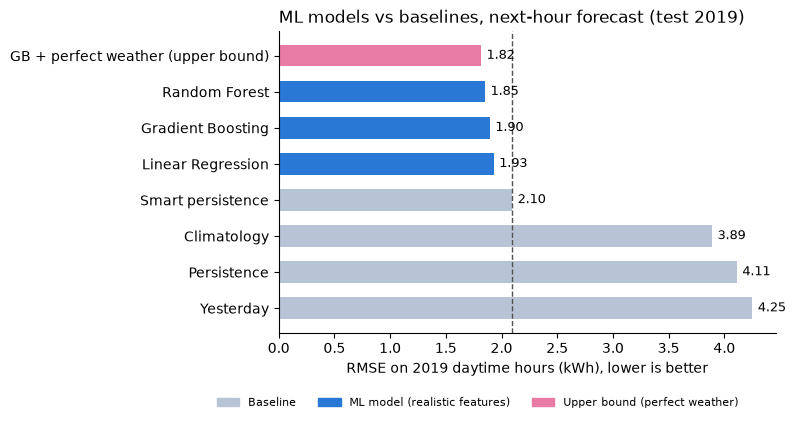

In [15]:
order = test_table.sort_values("RMSE (kWh)", ascending=False).index
kind = {n: "baseline" for n in baselines} | {"Linear Regression": "ml", "Random Forest": "ml", "Gradient Boosting": "ml",
                                             "GB + perfect weather (upper bound)": "upper"}
color = {"baseline": "#b8c4d6", "ml": "#2a78d6", "upper": "#e87ba4"}

fig, ax = plt.subplots(figsize=(8, 4.4))
bars = ax.barh(order, test_table.loc[order, "RMSE (kWh)"], color=[color[kind[n]] for n in order], height=0.6)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.axvline(test_table.loc["Smart persistence", "RMSE (kWh)"], color="#52514e", linestyle="--", linewidth=1)
ax.set_xlabel("RMSE on 2019 daytime hours (kWh), lower is better")
ax.set_title("ML models vs baselines, next-hour forecast (test 2019)", loc="left")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in color.values()]
ax.legend(handles, ["Baseline", "ML model (realistic features)", "Upper bound (perfect weather)"],
          loc="upper center", bbox_to_anchor=(0.4, -0.18), ncol=3, frameon=False, fontsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "04_models_rmse.png", dpi=130)
plt.show()

## What does the model rely on? (permutation importance)

**Permutation importance:** shuffle one feature at a time and measure how much worse the model gets.
A big drop means the model relies on that feature. We measure it on **2018** data, with the Random
Forest trained on 2017.

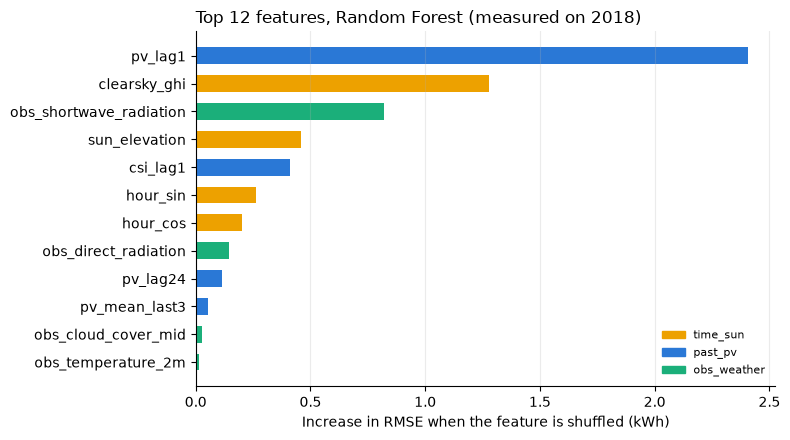

In [16]:
_, rf_2017 = fit_predict(forest(*rf_params), X, REALISTIC, ["train"])
val_rows = split(X, "val")
val_rows = val_rows[(val_rows["sun_elevation"] > 0) & val_rows["target"].notna()]

imp = permutation_importance(rf_2017, val_rows[REALISTIC], val_rows["target"], n_repeats=5,
                             scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1)
importance = pd.Series(imp.importances_mean, index=REALISTIC).sort_values(ascending=False)[:12]

group_of = {c: g for g, cols in FEATURE_SETS.items() for c in cols}
group_colors = {"time_sun": "#eda100", "past_pv": "#2a78d6", "obs_weather": "#1baf7a"}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importance.index[::-1], importance.values[::-1],
        color=[group_colors[group_of[c]] for c in importance.index[::-1]], height=0.6)
ax.set_xlabel("Increase in RMSE when the feature is shuffled (kWh)")
ax.set_title("Top 12 features, Random Forest (measured on 2018)", loc="left")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), loc="lower right", frameon=False, fontsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "04_feature_importance.png", dpi=130)
plt.show()

## One cloudy week, up close

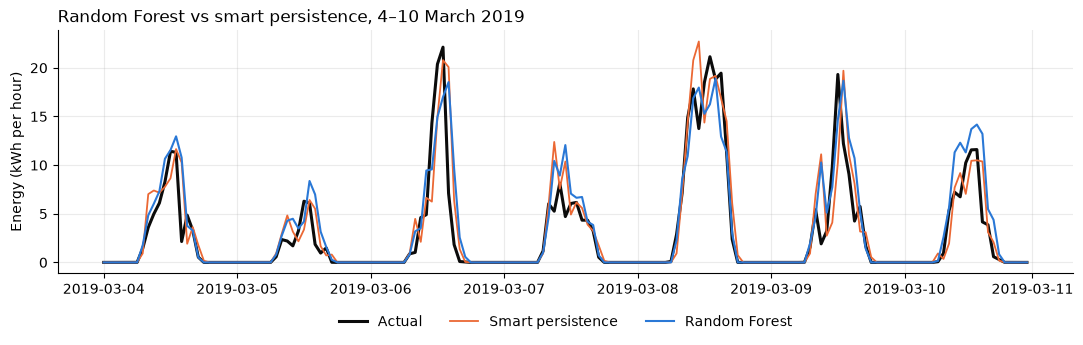

In [17]:
week = slice("2019-03-04", "2019-03-10")
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(y.loc[week].index, y.loc[week], color="#0b0b0b", linewidth=2.2, label="Actual")
ax.plot(test_forecasts["Smart persistence"].loc[week].index, test_forecasts["Smart persistence"].loc[week],
        color="#eb6834", linewidth=1.3, label="Smart persistence")
ax.plot(test_forecasts["Random Forest"].loc[week].index, test_forecasts["Random Forest"].loc[week],
        color="#2a78d6", linewidth=1.5, label="Random Forest")
ax.set_ylabel("Energy (kWh per hour)")
ax.set_title("Random Forest vs smart persistence, 4–10 March 2019", loc="left")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "04_week_rf_vs_smart.png", dpi=130)
plt.show()

In [18]:
out = pd.concat({"val": val_table, "test": test_table}, names=["split", "model"])
out.to_csv(RESULTS / "metrics_models.csv")
out

MAE (kWh)  RMSE (kWh)  nRMSE (%)  \
split model                                                                  
val   Persistence                             3.528       4.277     35.101   
      Yesterday                               2.470       4.430     36.354   
      Climatology                             2.660       4.089     33.552   
      Smart persistence                       1.308       2.216     18.187   
      Linear Regression                       1.377       2.115     17.359   
      Random Forest                           1.130       1.974     16.201   
      Gradient Boosting                       1.198       2.010     16.494   
test  Persistence                             3.403       4.112     34.035   
      Yesterday                               2.284       4.251     35.192   
      Climatology                             2.459       3.889     32.193   
      Smart persistence                       1.221       2.095     17.338   
      Linear Regression                       1.189       1.930     15.976   
      Random Forest                           0.989       1.852     15.329   
      Gradient Boosting                       1.066       1.895     15.684   
      GB + perfect weather (upper bound)      1.019       1.816     15.035   

                                          Skill vs persistence  
split model                                                     
val   Persistence                                        0.000  
      Yesterday                                         -0.036  
      Climatology                                        0.044  
      Smart persistence                                  0.482  
      Linear Regression                                  0.505  
      Random Forest                                      0.538  
      Gradient Boosting                                  0.530  
test  Persistence                                        0.000  
      Yesterday                                         -0.034  
      Climatology                                        0.054  
      Smart persistence                                  0.491  
      Linear Regression                                  0.531  
      Random Forest                                      0.550  
      Gradient Boosting                                  0.539  
      GB + perfect weather (upper bound)                 0.558

## What we learned

- **All three ML models beat smart persistence** on both 2018 and 2019. The best, **Random Forest**,
  lowers the 2019 RMSE from **2.10 to about 1.85 kWh**, roughly **11–12% less error**
  (skill about 0.55 vs 0.49). A real but modest gain, which is typical for next-hour solar forecasting.
- **The ranking is the same on 2018 and 2019**, so the result isn't luck.
- **The model relies mostly on last hour's solar power, physics** (clear-sky sunlight, sun position)
  **and last hour's observed sunlight.** The cloud-cover features add very little.
- **Even *perfect* weather barely helps.** This weather data describes grid squares about 9–25 km wide,
  so it can't see the individual clouds passing over one building.

**This motivates the next levels:**

- **Level 3:** predict a *range*, not just one number, because the errors are large on cloudy days.
- **Level 4:** use **sky camera images**, which *can* see the local clouds that weather data misses.